# Exam

> Data: **2024-07-26**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il dataset [Kaggle](https://www.kaggle.com/datasets/saurabhbadole/housing-price-data) contiene dati
relativi ad alcune case in vendita, tra cui:

- `price`: prezzo di vendita della proprietà
- `area`: area totale in square feet
- `bedrooms`: numero di camere da letto
- `bathrooms`: numero di bagni
- `stories`: numero di piani
- `mainroad`: indica se la proprietà si trova su una strada principale
- `guestroom`: indica se la proprietà dispone di una camera per gli ospiti
- `basement`: indica se la proprietà ha un seminterrato
- `hotwaterheating`: indica se la proprietà dispone di riscaldamento acqua calda
- `airconditioning`: indica se la proprietà dispone di aria condizionata
- `parking`: numero di posti auto disponibili
- `prefarea`: indica se la proprietà si trova in un'area preferita
- `furnishingstatus`: lo stato di arredo della proprietà.

La variabile da predire è `price`.

Nota: Il file csv che si trova al [link](https://bit.ly/4bUbfSx).

### Imports

In [ ]:
!curl -sLo dataset.zip "https://www.kaggle.com/api/v1/datasets/download/saurabhbadole/housing-price-data"
!unzip -o dataset.zip
!mv Housing_Price_Data.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

Archive:  dataset.zip
  inflating: Housing_Price_Data.csv  


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_log_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import FeatureUnion
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


#### Instances

In [ ]:
df.shape

(545, 13)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [ ]:
df["price"].value_counts()

,count
price,
4200000,17
3500000,17
4900000,12
5250000,9
5600000,9
...,...
2135000,1
1960000,1
1855000,1


<Axes: >

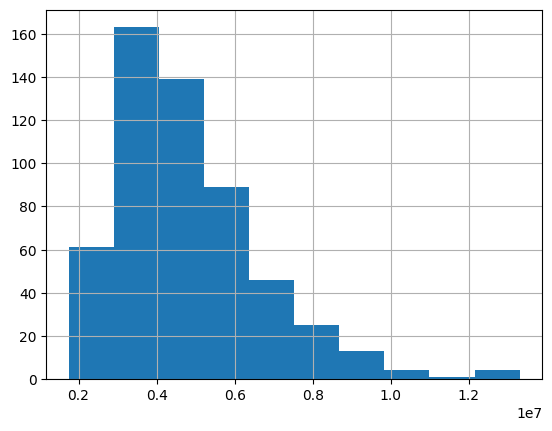

In [ ]:
df["price"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati - non esistono "missing values")?

In [ ]:
df.shape[0]

545

> Il dataset contiene 545 istanze.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

> Il dataset non contiene missing values, quindi il dataset è completo.

---

### Domanda 02 (Punti 3)

Verificare se è vero che le case situate su una strada principale sono quelle più costose. Considerando soltanto le case su strada principale, realizzare una pivot table attraverso la quale mostrare il prezzo medio delle case con / senza guestroom (sulle righe) con / senza seminterrato (colonne). Quale caratteristica tra guestroom e seminterrato comporta un aumento maggiore del prezzo della casa? Motivare la scelta.

#### Verificare se è vero che le case situate su una strada principale sono quelle più costose. (Punti 1)

In [ ]:
df.groupby("mainroad")["price"].mean()

,price
mainroad,
no,3.398905e+06
yes,4.991777e+06


> Si, le case situate su una strada principale hanno in media un prezzo maggiore delle case non situate su una strada principale.

#### Considerando soltanto le case su strada principale, realizzare una pivot table attraverso la quale mostrare il prezzo medio delle case con / senza guestroom (sulle righe) con / senza seminterrato (colonne). Quale caratteristica tra guestroom e seminterrato comporta un aumento maggiore del prezzo della casa? Motivare la scelta. (Punti 2)

In [ ]:
mainroad_df = df[df["mainroad"] == "yes"]
mainroad_df.pivot_table(index="guestroom", columns="basement", values="price", aggfunc="mean", observed=False)

basement,no,yes
guestroom,,
no,4.625947e+06,5.151417e+06
yes,6.277104e+06,5.807508e+06


> Considerando solamente la presenza di una delle due caratteristiche, quindi solamente seminterrato o solamente camera degli ospiti, quella che incide maggiormente sull'aumento del prezzo della casa è la camera degli ospiti.
>
> Inoltre, la presenza della camera degli ospiti porta un prezzo maggiore della casa anche rispetto alla presenza di entrambe le caratteristiche.

---

### Domanda 03 (Punti 3)

Rappresentare in un istogramma la distribuzione dei valori della feature `area`. Poi, raggruppare i valori secondo questa suddivisione: gruppo1 (1649-3660]; gruppo2 (3660-6150]; gruppo3 (6150-9150]; gruppo4 (9150-13150]; gruppo5 (13150-16200], e visualizzare in un nuovo istogramma la distribuzione nei gruppi. Infine, indicare per ogni gruppo il numero di istanze per ogni valore di `bedrooms`. Si può dire che le case più grandi hanno più camere da letto?

<Axes: >

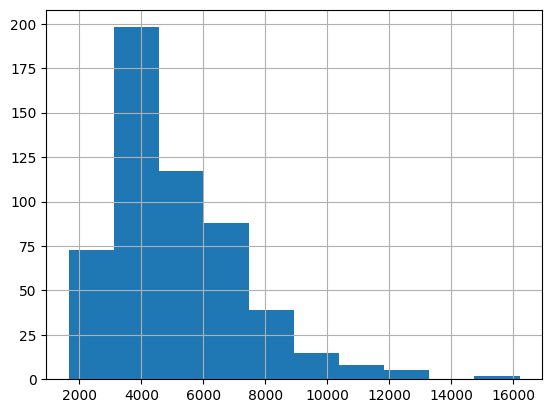

In [ ]:
df["area"].hist()

In [ ]:
groups = [1649, 3660, 6150, 9150, 13150, 16200]
labels = ["Group 1", "Group 2", "Group 3", "Group 4", "Group 5"]
area_bins = pd.cut(df["area"], bins=groups, labels=labels)
area_bins.value_counts()

,count
area,
Group 2,232
Group 1,164
Group 3,124
Group 4,21
Group 5,4


<Axes: >

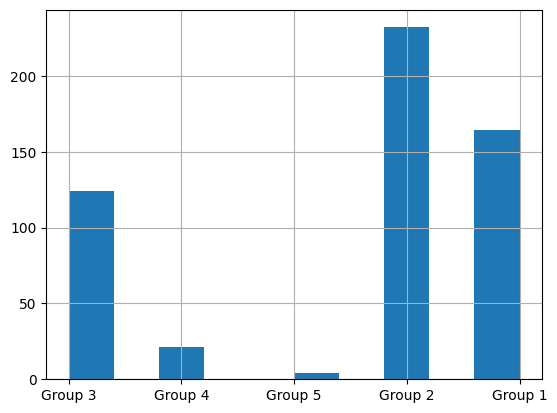

In [ ]:
area_bins.hist()

In [ ]:
pd.pivot_table(df, index=area_bins, columns="bedrooms", values="price", aggfunc="count", observed=False)

bedrooms,1,2,3,4,5,6
area,,,,,,
Group 1,1,55,84,20,3,1
Group 2,1,59,125,43,3,1
Group 3,0,16,78,27,3,0
Group 4,0,5,11,5,0,0
Group 5,0,1,2,0,1,0


> No, le case più grandi non necessariamente hanno più stanze delle case più piccole. Anzi, troviamo molte più case con metrature minori e maggior numero di stanze.

---

### Domanda 04 (Punti 3)

Considerare solo le case con almeno 2 bagni e almeno 2 camere da letto, rappresentare in uno scatterplot i valori di `price` (ascisse) e `area` (ordinate). Colorare i punti nel grafico in base alla presenza dell’aria condizionata. Usare i nomi dei due attributi come etichette di ascisse e ordinate.

<Axes: xlabel='price', ylabel='area'>

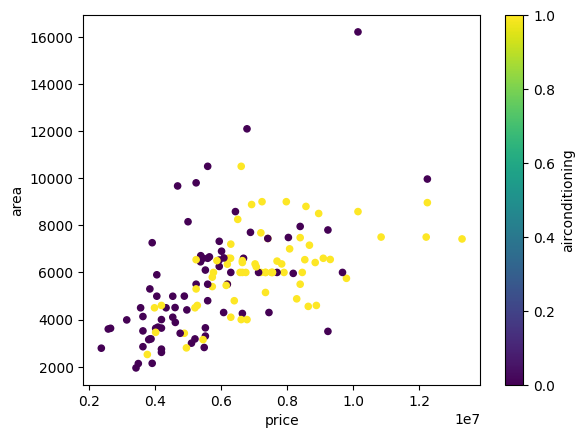

In [ ]:
mask_bathrooms = df["bathrooms"] >= 2
mask_bedrooms = df["bedrooms"] >= 2
df["airconditioning"] = df["airconditioning"].map({"yes": 1, "no": 0})
df[mask_bathrooms & mask_bedrooms].plot.scatter(
    x="price",
    y="area",
    c="airconditioning",
    cmap="viridis",
)

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire il prezzo di vendita delle case. Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta) ed eventuali istanze con valori nulli. Convertire i valori delle colonne `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea` in modo che "yes" sia sostituito con 1 e "no" con 0. Trasformare anche i valori testuali della colonna `furnishingstatus` in valori numerici a piacere. Dividere il dataset in modo che 3/4 degli elementi siano contenuti in un nuovo dataset "train" e 1/4 nel dataset "test".

Allenare il train con il modello LinearRegression e valutare il Mean Squared Logarithmic Error (MSLE) e R2 sia sul dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una predizione basata sul modello SGDRegressor. Effettuare alcune considerazioni sui risultati ottenuti.

In [ ]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)
categorical_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df[categorical_columns] = df[categorical_columns].apply(lambda column: column.map({"yes": 1, "no": 0}))
encoder = LabelEncoder()
df["furnishingstatus"] = encoder.fit_transform(df["furnishingstatus"])
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,2
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,2
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0


> Non è stato necessario rimuovere nessun attributo dal dataset.

In [ ]:
X, y = df.drop("price", axis=1), df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0)

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "SGDRegressor": SGDRegressor(learning_rate="optimal", random_state=0),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}:")
    print("=" * 30)
    print("TRAIN")
    print("    MSLE:", mean_squared_log_error(y_train, y_pred_train))
    print("    R2:", r2_score(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    MSLE:", mean_squared_log_error(y_test, y_pred_test))
    print("    R2:", r2_score(y_test, y_pred_test))
    print("=" * 30)
    print()

LinearRegression:
TRAIN
    MSLE: 0.0471743205506263
    R2: 0.6707984521479506
------------------------------
TEST
    MSLE: 0.04295276370186967
    R2: 0.6965206541388419

SGDRegressor:
TRAIN
    MSLE: 700.3670518335607
    R2: -7.101855299597608e+23
------------------------------
TEST
    MSLE: 701.8218121341064
    R2: -9.614415119763551e+23



> Il modello `Linear` stando alle metriche sembra lavorare abbastanza bene. Infatti, il valore ottimale per la metrica MSLE è 0 e il modello ha ottenuto un valore molto vicino ad esso. Allo stesso modo, il valore ottimale per la metrica R2 è 1, e anche in questo caso, il modello ha ottenuto un valore abbastanza vicino ad esso. Quindi il modello non sta lavorando male.
>
> Il modello `SGD`, invece, non lavora molto bene. Infatti la metrica MSLE è sui 700, abbastanza lontano dall'ottimale. Così come anche per R2, ottenendo addirittura un valore negativo, indicando quanto il modello non stia lavorando correttamente.

---

### Domanda 02 (Punti 1)

Confrontare i valori di R2 ottenuti nel punto precedente con il valore di R2 che si ottiene con una 5 Fold cross validation.

In [ ]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"{name}:")
    print("=" * 30)
    print("    R2:", scores.mean())
    print("    R2 scores:", scores)
    print("=" * 30)
    print()

LinearRegression:
    R2: -9.91067677307725
    R2 scores: [ -1.94277003  -5.00707214 -16.22431367 -21.10749485  -5.27173317]

SGDRegressor:
    R2: -1.3341287745103151e+26
    R2 scores: [-2.83830550e+24 -1.66267902e+26 -1.93538911e+26 -2.71435618e+26
 -3.29836508e+25]



> Le metriche mostrate a seguito della 5 fold cross validation mostrano dei peggioramenti nelle performance, per entrambi i modelli.

---

### Domanda 03 (Punti 3)

Trovare i parametri migliori di SGDRegressor, agendo sui parametri `loss` e `penalty`. Scegliere alcuni valori da testare e riportare i valori di MSLE e R2 ottenuti con la migliore configurazione, confrontare questi valori con quelli ottenuti al punto 1.

In [ ]:
sgd = models["SGDRegressor"]

params = {
    "loss": ["squared_error", "huber", "epsilon_insensitive", "squared_epsilon_insensitive"],
    "penalty": ["l1", "l2", "elasticnet", None],
}
grid_search = GridSearchCV(
    estimator=sgd,
    param_grid=params,
    scoring="r2",
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("MSLE:", mean_squared_log_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

Best parameters: {'loss': 'huber', 'penalty': 'l1'}
Best score: -0.12089857094323105
MSLE: 0.21339401811270464
R2: -0.14029327047329598


> Attraverso il `GridSearchCV` il modello `SGD` ottiene un miglioramento netto delle performance. Infatti la metrica MSLE arriva molto vicina a 0, mentre la metrica R2 aumenta rispetto a quella analizzata inzialmente.
>
> I parametri ottimali ottenuti per `loss` e `penality` sono rispettivamente `huber` e `l1`.

---

### Domanda 04 (Punti 3)

Studiare la correlazione tra le feature del dataset, creare un dataframe che contiene, oltre alla colonna target, le 5 feature più correlate (positivamente) al target. Ripetere la predizione sul nuovo dataset e verificare se il MSLE ottenuto con LinearRegression e SGDRegressor migliora.

In [ ]:
correlation = df.corr()["price"].sort_values(ascending=False)[:6]
df_correlation = df[correlation.index]
df_correlation

,price,area,bathrooms,airconditioning,stories,parking
0,13300000,7420,2,1,3,2
1,12250000,8960,4,1,4,3
2,12250000,9960,2,0,2,2
3,12215000,7500,2,1,2,3
4,11410000,7420,1,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,1,0,1,2
541,1767150,2400,1,0,1,0
542,1750000,3620,1,0,1,0
543,1750000,2910,1,0,1,0


In [ ]:
X_correlation, y_correlation = df_correlation.drop("price", axis=1), df_correlation["price"]
X_train, X_test, y_train, y_test = train_test_split(X_correlation, y_correlation, test_size=1/4, random_state=0)

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}:")
    print("=" * 30)
    print("TRAIN")
    print("    MSLE:", mean_squared_log_error(y_train, y_pred_train))
    print("    R2:", r2_score(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    MSLE:", mean_squared_log_error(y_test, y_pred_test))
    print("    R2:", r2_score(y_test, y_pred_test))
    print("=" * 30)
    print()

LinearRegression:
TRAIN
    MSLE: 0.0620865910672465
    R2: 0.5771289342002002
------------------------------
TEST
    MSLE: 0.043215909870790985
    R2: 0.6854980377485653

SGDRegressor:
TRAIN
    MSLE: 700.3665840786873
    R2: -7.101827734905518e+23
------------------------------
TEST
    MSLE: 701.8214839152256
    R2: -9.614405514396373e+23



> Le metriche tornano ad essere in linea con quelle viste inizialmente, per entrambi i modelli.

---

### Domanda 05 (Punti 3)

Considerare il dataset usato al punto 1, creare una pipeline in cui al dataset normalizzato si aggiunga una colonna che contiene i valori della colonna `area` discretizzati in 5 intervalli. La pipeline deve applicare il modello SGDRegressor con i parametri migliori trovati al punto 3. Valutare MSLE e R2 della predizione.

In [ ]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)
categorical_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df[categorical_columns] = df[categorical_columns].apply(lambda column: column.map({"yes": 1, "no": 0}))
encoder = LabelEncoder()
df["furnishingstatus"] = encoder.fit_transform(df["furnishingstatus"])

In [ ]:
X, y = df.drop("price", axis=1), df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0)

In [ ]:
scaler = Normalizer()

column_scaler = ColumnTransformer(
    transformers=[
        ("scaler", scaler, X.columns),
    ],
    force_int_remainder_cols=False,
)
column_scaler

ColumnTransformer(force_int_remainder_cols=False,
                  transformers=[('scaler', Normalizer(),
                                 Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object'))])

In [ ]:
discretizer = KBinsDiscretizer(n_bins=5)

column_discretizer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, ["area"]),
    ],
    force_int_remainder_cols=False,
)
column_discretizer

ColumnTransformer(force_int_remainder_cols=False,
                  transformers=[('discretizer', KBinsDiscretizer(), ['area'])])

In [ ]:
feature_union = FeatureUnion(
    transformer_list=[
        ("column_scaler", column_scaler),
        ("column_discretizer", column_discretizer),
    ],
)
feature_union

FeatureUnion(transformer_list=[('column_scaler',
                                ColumnTransformer(force_int_remainder_cols=False,
                                                  transformers=[('scaler',
                                                                 Normalizer(),
                                                                 Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object'))])),
                               ('column_discretizer',
                                ColumnTransformer(force_int_remainder_cols=False,
                                                  transformers=[('discretizer',
                                                                 KBinsDiscretizer(),
                                                                 ['area'])]))])

In [ ]:
best_loss = grid_search.best_params_["loss"]
best_penality = grid_search.best_params_["penalty"]
sgd = SGDRegressor(loss=best_loss, penalty=best_penality, learning_rate="optimal", random_state=0)

pipeline = Pipeline(
    steps=[
        ("feature_union", feature_union),
        ("sgd", sgd),
    ],
)
pipeline

Pipeline(steps=[('feature_union',
                 FeatureUnion(transformer_list=[('column_scaler',
                                                 ColumnTransformer(force_int_remainder_cols=False,
                                                                   transformers=[('scaler',
                                                                                  Normalizer(),
                                                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object'))])),
                                                ('column_discretizer',
                                                 ColumnTransformer(force_int_remainder_cols=False,
                                                                   transformers=[('discretizer',
                                                                                  KBinsDiscretizer(),
                                                                                  ['area'])]))])),
                ('sgd',
                 SGDRegressor(learning_rate='optimal', loss='huber',
                              penalty='l1', random_state=0))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("MSLE:", mean_squared_log_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSLE: 41.03779519306282
R2: -6.966962030114055


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


> Anche attraverso questa pipeline, il modello `SGD` non ottiene ottime performance.

---

### Domanda 06 (Punti 3)

Aggiungere in coda alla pipeline la funzione SelectKBest. Utilizzare la funzione di gridSearchCV per selezionare il K migliore e anche gli intervalli migliori in cui discretizzare i valori di `area`. Ignorare eventuali warning.

In [ ]:
k_best = SelectKBest()

pipeline = Pipeline(
    steps=[
        ("feature_union", feature_union),
        ("k_best", k_best),
        ("sgd", sgd),
    ],
)
pipeline

Pipeline(steps=[('feature_union',
                 FeatureUnion(transformer_list=[('column_scaler',
                                                 ColumnTransformer(force_int_remainder_cols=False,
                                                                   transformers=[('scaler',
                                                                                  Normalizer(),
                                                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object'))])),
                                                ('column_discretizer',
                                                 ColumnTransformer(force_int_remainder_cols=False,
                                                                   transformers=[('discretizer',
                                                                                  KBinsDiscretizer(),
                                                                                  ['area'])]))])),
                ('k_best', SelectKBest()),
                ('sgd',
                 SGDRegressor(learning_rate='optimal', loss='huber',
                              penalty='l1', random_state=0))])

In [ ]:
params = {
    "k_best__k": [1, 2, 3, 4, 5],
    "feature_union__column_discretizer__discretizer__n_bins": [2, 3, 4, 5, 6],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring="r2",
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("MSLE:", mean_squared_log_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

Best parameters: {'feature_union__column_discretizer__discretizer__n_bins': 2, 'k_best__k': 4}
Best score: -6.811940225976985
MSLE: 38.327028262741045
R2: -6.961718633315561


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


> Come nel precedente punto, anche in questo le metriche non migliorano per il modello.

---

### Domanda 07 (Punti 3)

Considerare il dataset usato al punto 1, creare una nuova pipeline in cui gli attributi `bedrooms`, `bathrooms` e `stories` sono discretizzati in 2 intervalli, l’attributo `area` è trasformato con uno StandardScaler e tutti gli altri attributi sono lasciati invariati. La pipeline deve applicare il modello SGDRegressor con i parametri migliori trovati al punto 3. Valutare i risultati ottenuti e confrontarli con quelli ottenuti al punto 5.

In [ ]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)
categorical_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
df[categorical_columns] = df[categorical_columns].apply(lambda column: column.map({"yes": 1, "no": 0}))
encoder = LabelEncoder()
df["furnishingstatus"] = encoder.fit_transform(df["furnishingstatus"])

In [ ]:
discretizer = KBinsDiscretizer(n_bins=2)
scaler = StandardScaler()

column_transformer = ColumnTransformer(
    transformers=[
        ("discretized", discretizer, ["bedrooms", "bathrooms", "stories"]),
        ("scaler", scaler, ["area"]),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('discretized', KBinsDiscretizer(n_bins=2),
                                 ['bedrooms', 'bathrooms', 'stories']),
                                ('scaler', StandardScaler(), ['area'])])

In [ ]:
sgd = SGDRegressor(loss=best_loss, penalty=best_penality, learning_rate="optimal", random_state=0)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("sgd", sgd),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discretized',
                                                  KBinsDiscretizer(n_bins=2),
                                                  ['bedrooms', 'bathrooms',
                                                   'stories']),
                                                 ('scaler', StandardScaler(),
                                                  ['area'])])),
                ('sgd',
                 SGDRegressor(learning_rate='optimal', loss='huber',
                              penalty='l1', random_state=0))])

In [ ]:
X, y = df.drop("price", axis=1), df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=0)

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("MSLE:", mean_squared_log_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSLE: 23.814112020083858
R2: -6.8840907641605025


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


> Diversa pipeline, ma le metriche non si discostano troppo. Il risultato risulta essere simile ai precedenti.